## Computer Vision - Part 7

### SCARA Robot Forward Kinematics

SCARA (Selective Compliance Assembly Robot Arm) robots are widely used in industrial applications for tasks such as assembly, pick-and-place, and packaging. The forward kinematics of a SCARA robot involves determining the position and orientation of the end effector (the tool or gripper at the end of the robot arm) based on the joint angles and link lengths.

Computing the SCARA robot's forward kinematics begins with determining joint twists in the reference configuration:

<img src="cpv-images/scara_robot1.png" width=600px height=400px />

To construct the twists for the revolute joints, note that:
$$𝜔_1 = 𝜔_2 = 𝜔_3 = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$$

Why $𝜔_3 = 1$? Because the third joint is a prismatic joint, which means it allows linear motion along its axis. In this case, the axis of motion is along the z-axis, so the twist for the prismatic joint is represented as a linear velocity along the z-axis, which is why $𝜔_3$ is set to 1.

We choose three axis points for the revolute joints as follows:
$$q_1 = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}, q_2 = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}, q_3 = \begin{bmatrix} 0 \\ 0 \\ l_1 + l_2 \end{bmatrix}$$

The yield twists for the three joints are then given by:
$$\xi_1 = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 1 \end{bmatrix}, \xi_2 = \begin{bmatrix} l_1 \\ 0 \\ 1 \\ 0 \\ 0 \\ 1 \end{bmatrix}, \xi_3 = \begin{bmatrix} l_1 + l_2 \\ 0 \\ 1 \\ 0 \\ 0 \\ 1 \end{bmatrix}, \xi_4 = \begin{bmatrix} v_4 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \\ 0 \\ 0 \end{bmatrix}$$

Why four twists? Because the SCARA robot has three revolute joints and one prismatic joint, resulting in a total of four degrees of freedom that need to be accounted for in the forward kinematics calculations.

The forward kinematics can then be computed using the product of exponentials formula, which combines the twists and joint angles to determine the end effector's position and orientation in space.

$$T_E = (e^{\hat{\xi_1} \theta_1} e^{\hat{\xi_2} \theta_2} e^{\hat{\xi_3} \theta_3} e^{\hat{\xi_4} d_4}) T_E(0)$$

- Where $T_E$ is the transformation matrix representing the end effector's pose, $\theta_i$ are the joint angles for the revolute joints, $d_4$ is the linear displacement for the prismatic joint, and $M$ is the home configuration of the end effector.

- $T_E(0)$ represents the home configuration of the end effector, which is the position and orientation of the end effector when all joint angles are at their zero positions. This serves as a reference point for calculating the forward kinematics as the robot moves from its home configuration to its desired pose based on the joint angles and displacements.

In Python, we can implement the forward kinematics using the following code:

In [63]:
!pip install roboticstoolbox-python


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [64]:
import numpy as np
from spatialmath import SE3, Twist3
from roboticstoolbox import PoERevolute, PoEPrismatic, robot

In [65]:
# SCARA Robot parameters
L1 = 0.4 # Length of the first link (m)
L2 = 0.3 # Length of the second link (m)
L3 = 0.2 # Length of the third link (prismatic joint to end effector) (m)

# Step 1: Determine T0, the home configuration of the end effector
# This is when all the joint angles are at their zero positions
T0 = SE3.Trans(0, L1 + L2, L3)

In [66]:
# Step 2: Determine the twists for each joint
omega1 = [0, 0, 1] # This is Z-axis rotation for the first revolute joint
omega2 = [0, 0, 1] # This is Z-axis rotation for the second revolute joint
omega3 = [0, 0, 1] # This is Z-axis rotation for the third revolute joint

q1 = [0, 0, 0] # Axis point for the first revolute joint
q2 = [0, L1, 0] # Axis point for the second revolute joint
q3 = [0, L1 + L2, 0] # Axis point for the third revolute joint
v4 = [0, 0, 1] # This is the linear velocity for the prismatic joint

xi1_coords = PoERevolute(omega1, q1)
xi2_coords = PoERevolute(omega2, q2)
xi3_coords = PoERevolute(omega3, q3)
xi4_coords = PoEPrismatic(v4) # This is the prismatic joint

In [67]:
# Step 3: Check with the specific twist angles
# [45 degrees, 30 degrees, 60 degrees, 0.1 m]
q = [np.pi/4, np.pi/6, np.pi/3, 0.1] # Joint angles for the revolute joints and linear displacement for the prismatic joint

In [68]:
# uSe Robot Class to compute forward kinematics
SCARA = robot.PoERobot([xi1_coords, xi2_coords, xi3_coords, xi4_coords], T0)
TE = SCARA.fkine(q)
SCARA.fkine(q).printline()

t = -0.573, 0.36, 0.3; rpy/zyx = 0°, 0°, 135°


### Task: Compute the forward kinematics 

Compute the forward kinematics  for a SCARA robot given specific joint angles and link lengths. The code will calculate the transformation matrix representing the end effector's pose based on the product of exponentials formula.

<img src="cpv-images/scara_robot2.png" width=600px height=400px />

To determine the w and q for the twists, we can use the following code. The easiest way is to use the right-hand rule to determine the direction of the angular velocity vector (w) for each joint, and then use the position of the joint (q) to compute the linear velocity component of the twist.

In [69]:
# We reuse the Link lengths for the next part of the notebook
L0 = 0.1 # Base height of the robot (m)
L1 = 0.4 
L2 = 0.3 

# Determine the twists for each joint
omega1 = [0, 0, 1] # This is Z-axis rotation for the first revolute joint
omega2 = [-1, 0, 0] # This is X-axis rotation for the second revolute joint
omega3 = [-1, 0, 0] # This is X-axis rotation for the third revolute joint
omega4 = [0, 0, 1] # This is Z-axis rotation for the fourth revolute joint
omega5 = [-1, 0, 0] # This is X-axis rotation for the fifth revolute joint
omega6 = [0, 1, 0] # This is Y-axis rotation for the sixth revolute joint

# Determine axis point
q1 = [0, 0, L0] # Axis point for the first revolute joint
q2 = [0, 0, L0] # Axis point for the second revolute joint
q3 = [0, L1, L0] # Axis point for the third revolute joint
q4 = [0, L1 + L2, L0] # Axis point for the fourth revolute joint
q5 = [0, L1 + L2, L0] # Axis point for the fifth revolute joint
q6 = [0, L1 + L2, L0] # Axis point for the sixth revolute joint

In [70]:
# We get the epsilon coordinates for each joint using the PoE method
xi1_coords = PoERevolute(omega1, q1)
xi2_coords = PoERevolute(omega2, q2)
xi3_coords = PoERevolute(omega3, q3)
xi4_coords = PoERevolute(omega4, q4)
xi5_coords = PoERevolute(omega5, q5)
xi6_coords = PoERevolute(omega6, q6)

q = [np.pi/4, np.pi/6, np.pi/3, 0.1]
SCARA = robot.PoERobot([xi1_coords, xi2_coords, xi3_coords, xi4_coords, xi5_coords, xi6_coords], T0)
TE = SCARA.fkine(q)
SCARA.fkine(q).printline()

t = -0.316, 0.316, -0.4; rpy/zyx = -90°, 5.73°, 45°


### 6-DOF Arm FK

In this example, we will compute the forward kinematics for a 6-DOF robotic arm using the Denavit-Hartenberg convention. The robot has six revolute joints, and we will define the link lengths and joint angles to calculate the end effector's position and orientation in space.

The Yahboom 6-DOF arm is the physical platform for manipulation labs. Joint angles are read from servo encoders or set via software commands. The FK model then computes the real-time TCP pose.

Yahboom uses an identical call pattern once its URDF or ETS model is loaded — same API, different model file.

In [71]:
import roboticstoolbox as rtb
import numpy as np

# Load Panda from URDF (7-DOF, similar workflow to Yahboom 6-DOF)
robot = rtb.models.URDF.Panda()
configs = {"zero pose (qz)": robot.qz, 
           "ready pose (qr)": robot.qr,}

for name, q in configs.items():
    T = robot.fkine(q)
    print(f"\n--- {name} ---")
    print(f" Joint angles (rad): {np.round(q, 3)}")
    print(f" TCP position (m): {np.round(T.t, 4)}")
    print(f" TCP rotation:\n{np.round(T.R, 4)}")


--- zero pose (qz) ---
 Joint angles (rad): [0. 0. 0. 0. 0. 0. 0.]
 TCP position (m): [ 0.088  -0.      0.8226]
 TCP rotation:
[[ 0.7071  0.7071  0.    ]
 [ 0.7071 -0.7071 -0.    ]
 [-0.      0.     -1.    ]]

--- ready pose (qr) ---
 Joint angles (rad): [ 0.    -0.3    0.    -2.2    0.     2.     0.785]
 TCP position (m): [ 0.484  -0.      0.4126]
 TCP rotation:
[[ 0.995  -0.      0.0998]
 [-0.     -1.     -0.    ]
 [ 0.0998  0.     -0.995 ]]


### Mobile Robot FK

Mobile robots, such as differential drive or omnidirectional robots, have their own unique kinematic models. The forward kinematics for a mobile robot involves calculating the robot's position and orientation based on its wheel velocities and the geometry of the robot.

The Unicycle Model is a common kinematic model for mobile robots, where the robot's motion is described by its linear velocity (v) and angular velocity (ω). The forward kinematics can be computed using the following equations:

### Discrete-Time Unicycle FK Step

Using Numpy, we can implement the discrete-time forward kinematics step for a unicycle model as follows:

This Euler integration approximates the continuous ODE with step size $\Delta t$. Accuracy improves with smaller $\Delta t$. For the upcoming lab, use $\Delta t = 0.1s$ and run for 100 steps.

In [72]:
import numpy as np
def unicycle_step(x, y, th, v, w, dt):
    """
    Euler integration of unicycle kinematics.
    Inputs: current pose (x,y,th), velocities (v,w), timestep dt
    Outputs: next pose (x_new, y_new, th_new)
    """
    x_new = x + v * np.cos(th) * dt
    y_new = y + v * np.sin(th) * dt
    th_new = th + w * dt
    return x_new, y_new, th_new

### From Wheel Speeds to Unicycle Inputs

Given left/right wheel speeds $v_L, v_R$ and wheel separation $W$:
$$v = \frac{v_L + v_R}{2}$$
$$\omega = \frac{v_R - v_L}{W}$$

Feed $(v, \omega)$ into `unicycle_step()` — the same function handles both models. The only difference is how the inputs are derived from hardware commands.

## Hands-on Lab

Nine progressive lab exercises building FK intuition from scratch — code first, theory second.

### Planar 2R FK — Manual Implementation

Manually implement the forward kinematics for a planar 2R robot arm using the product of exponentials formula. Define the joint angles and link lengths, and compute the end effector's position in the plane.

- Implement `fk_2r()` and test with multiple $(\theta_1, \theta_2)$ pairs
- Generate and plot the full TCP workspace via grid sweep
- Identify the reachable annulus: inner radius $|l_1 - l_2|$ , outer $l_1 + l_2$

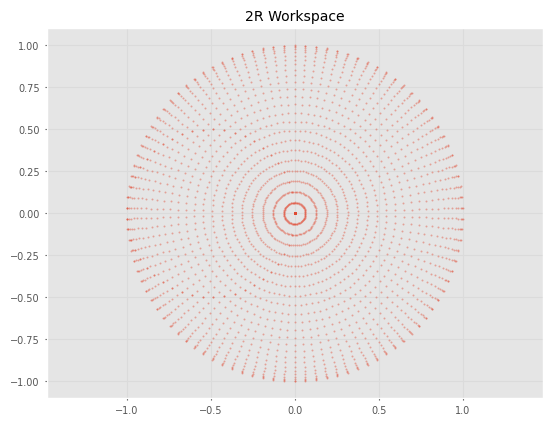

In [73]:
import numpy as np
import matplotlib.pyplot as plt

def fk_2r(l1, l2, th1, th2):
    x = l1*np.cos(th1) + l2*np.cos(th1 + th2)
    y = l1*np.sin(th1) + l2*np.sin(th1 + th2)
    return x, y

# Plot workspace
l1 = l2 = 0.5
pts = []
for t1 in np.linspace(-np.pi, np.pi, 50):
    for t2 in np.linspace(-np.pi, np.pi, 50):
        x, y = fk_2r(l1, l2, t1, t2)
        pts.append((x, y))

xs, ys = zip(*pts)
plt.scatter(xs, ys, s=1, alpha=0.3)
plt.axis('equal')
plt.title("2R Workspace"); plt.show()

### Planar 2R FK via Robotics Toolbox

The Robotics Toolbox provides built-in functions for computing forward kinematics. Use the toolbox to implement the forward kinematics for a planar 2R robot arm, and compare the results with your manual implementation.

- Run `robot.fkine(q)` for each configuration above
- Compare outputs with your `fk_2r()` from previous lab
- Confirm numerical agreement to 4 decimal places

In [74]:
import roboticstoolbox as rtb
import numpy as np
robot = rtb.models.ETS.Planar2()

# Test configurations
configs = [np.array([0.0, 0.0]), # zero configuration, 
           np.array([0.3, 0.7]), # arbitrary 
           np.array([np.pi/4, np.pi/3])]

for q in configs:
    T = robot.fkine(q)
    print(f"q = {np.round(q,3)} → TCP = {np.round(T.t[:2], 4)}")

q = [0. 0.] → TCP = [2. 0.]
q = [0.3 0.7] → TCP = [1.4956 1.137 ]
q = [0.785 1.047] → TCP = [0.4483 1.673 ]


#### Workspace Sweep — Visualizing Reachability

Scan a fine grid of $(\theta_1, \theta_2)$ values, compute $(x, y)$ for each, and plot the resulting scatter. Add joint limits to reveal the constrained workspace.

What to Observe:

- Full reachable annulus with $0 \leq r \leq l_1 + l_2$
- Effect of restricting $\theta_2 \in [0°, 180°]$
- Singular configurations: fully extended and fully folded

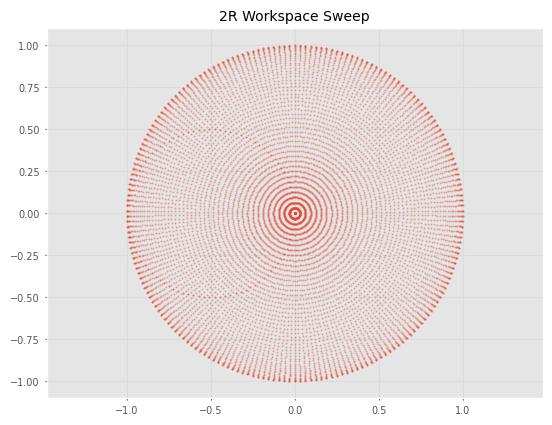

In [75]:
th_range = np.linspace(-np.pi, np.pi, 100)
xs, ys = [], []

for t1 in th_range:
    for t2 in th_range:
        x, y = fk_2r(0.5, 0.5, t1, t2)
        xs.append(x); ys.append(y)

plt.scatter(xs, ys, s=1, alpha=0.3)
plt.axis('equal')
plt.title("2R Workspace Sweep"); plt.show()

#### 6-DOF FK — Panda / Yahboom

Yahboom's 6-DOF arm is the physical platform for manipulation labs. Joint angles are read from servo encoders or set via software commands. The FK model then computes the real-time TCP pose.

Panda's 6-DOF arm is a common research platform. Use the Robotics Toolbox to compute FK for the Panda, and compare with Yahboom results. This reinforces that FK is model-specific, but the API remains consistent across platforms.

Yahboom 6-DOF uses the same `fkine(q)` call once its URDF or ETS model is imported — same API, different model file. This allows you to easily switch between the two platforms and compare their forward kinematics results.

In [76]:
import roboticstoolbox as rtb
import numpy as np

robot = rtb.models.URDF.Panda()
# Test multiple configurations
configs = {"zero (qz)": robot.qz, 
           "ready (qr)": robot.qr, 
           "random": np.random.uniform(-1, 1, robot.n)}

for name, q in configs.items():
    T = robot.fkine(q)
    print(f"\n[{name}]")
    print(f" Joints: {np.round(q, 3)}")
    print(f" Position: {np.round(T.t, 4)} m")
    print(f" Rotation:\n{np.round(T.R, 3)}")


[zero (qz)]
 Joints: [0. 0. 0. 0. 0. 0. 0.]
 Position: [ 0.088  -0.      0.8226] m
 Rotation:
[[ 0.707  0.707  0.   ]
 [ 0.707 -0.707 -0.   ]
 [-0.     0.    -1.   ]]

[ready (qr)]
 Joints: [ 0.    -0.3    0.    -2.2    0.     2.     0.785]
 Position: [ 0.484  -0.      0.4126] m
 Rotation:
[[ 0.995 -0.     0.1  ]
 [-0.    -1.    -0.   ]
 [ 0.1    0.    -0.995]]

[random]
 Joints: [-0.131  0.444  0.247 -0.58  -0.286 -0.036  0.939]
 Position: [ 0.3531 -0.0264  0.676 ] m
 Rotation:
[[ 0.479 -0.133 -0.868]
 [-0.298 -0.955 -0.018]
 [-0.826  0.267 -0.497]]


### Visualization with Swift — Interactive FK

Use Swift's 3D visualization capabilities to create an interactive forward kinematics demo. Visualize the robot arm in 3D, allowing users to manipulate joint angles with sliders and see the resulting end effector pose in real-time. This hands-on experience will deepen your understanding of how joint configurations affect the robot's workspace and reachability.

Steps:
1. Launch Swift: `robot.plot(q, backend='swift')`
2. Use the joint sliders to move each DOF interactively
3. Observe the TCP trace path in real time
4. Screenshot at least two distinct poses for the lab report

In [77]:
# Swift visualization (interactive)
# robot.plot(robot.qz, backend='swift')

### Unicycle FK — Trajectory Simulation

Simulate a unicycle robot following a predefined trajectory. Define a sequence of linear and angular velocities, and use the discrete-time forward kinematics to compute the robot's path over time. Visualize the trajectory in a 2D plot.

With constant $v = 0.1m/s$ and $\omega = 0.2rad/s$, the robot traces a circular arc of radius $r = v/\omega = 0.5m$. 

Run the simulation for 100 steps with $\Delta t = 0.1s$, and plot the resulting trajectory to visualize the unicycle's motion.

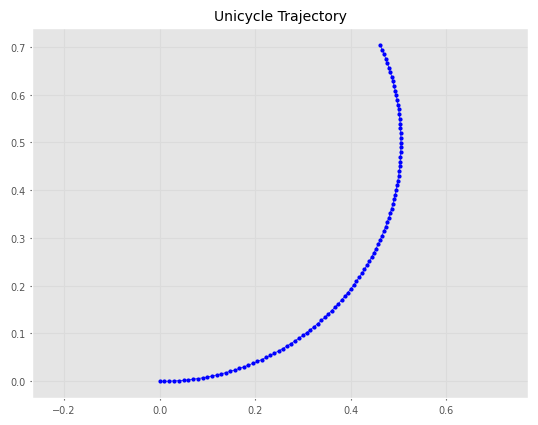

In [78]:
import numpy as np
import matplotlib.pyplot as plt

def unicycle_step(x, y, th, v, w, dt):
    return (x + v*np.cos(th)*dt,
            y + v*np.sin(th)*dt,
            th + w*dt)

# Simulate 100 steps with constant v and omega
x, y, th = 0.0, 0.0, 0.0
v, w, dt = 0.1, 0.2, 0.1 # m/s, rad/s, s
traj = [(x, y)]

for _ in range(100):
    x, y, th = unicycle_step(x, y, th, v, w, dt)
    traj.append((x, y))

xs, ys = zip(*traj)
plt.plot(xs, ys, 'b-o', markersize=2)
plt.axis('equal'); plt.title("Unicycle Trajectory"); plt.show()

### Differential Drive FK

Implement the forward kinematics for a differential drive robot. Given the left and right wheel velocities, compute the robot's linear and angular velocities, and then use these to update the robot's position and orientation over time. Visualize the resulting trajectory in a 2D plot.

In [79]:
def diff_drive_to_unicycle(v_L, v_R, W):
    """
    Convert differential drive wheel speeds to unicycle model.
    W: wheel track width (distance between wheels in meters)
    """
    v = (v_R + v_L) / 2.0
    w = (v_R - v_L) / W
    return v, w

# Example: left wheel faster → turns right
W = 0.3 # 30 cm track width
v_L, v_R = 0.08, 0.12
v, w = diff_drive_to_unicycle(v_L, v_R, W)
print(f"v = {v:.3f} m/s, omega = {w:.3f} rad/s")
print(f"Turning radius = {v/w:.3f} m")

v = 0.100 m/s, omega = 0.133 rad/s
Turning radius = 0.750 m


Set `v_L = 0, v_R = 0.1` → robot rotates around its left wheel. Set `v_L = -v_R` → robot spins in place

In [80]:
v_L, v_R = 0, 0.1
v, w = diff_drive_to_unicycle(v_L, v_R, W)
print(f"v = {v:.3f} m/s, omega = {w:.3f} rad/s")
print(f"Turning radius = {v/w:.3f} m (rotating around left wheel)")

v = 0.050 m/s, omega = 0.333 rad/s
Turning radius = 0.150 m (rotating around left wheel)


## Toy Example: Base + Arm Combined

A mobile manipulator must reach a fixed object:
1. Use unicycle FK to drive the base forward 1 m
2. Use arm FK (fixed ready-pose) to compute TCP in base frame
3. Compute TCP in world frame: 

$$T_{\text{world}}^{\text{TCP}} =
   T_{\text{world}}^{\text{base}} \cdot
   T_{\text{base}}^{\text{TCP}}$$

No IK needed yet — just FK composition. Shows how base motion changes the world-frame TCP even when arm joints are fixed

In [81]:
import roboticstoolbox as rtb
import numpy as np
from spatialmath import SE2, SE3

# Use unicycle FK to drive the base forward 1 m
x0, x1 = np.array([0, 0, 0]), np.array([1, 0, 0]) # Start at origin, move to (1,0)
T0 = SE2(x0) # Initial pose
T1 = SE2(x1) # Final pose
print(f"Initial pose:\n{T0}\nFinal pose:\n{T1}")

unicycle_traj = SE2.interp(T0, T1, 10) # Interpolate 10 steps
print("\nUnicycle trajectory:")
for i, T in enumerate(unicycle_traj):
    print(f"Step {i}:\n {T}")


Initial pose:
   1         0         0         
   0         1         0         
   0         0         1         

Final pose:
   1         0         1         
   0         1         0         
   0         0         1         


Unicycle trajectory:
Step 0:
    1         0         0         
   0         1         0         
   0         0         1         

Step 1:
    1         0         0.1111    
   0         1         0         
   0         0         1         

Step 2:
    1         0         0.2222    
   0         1         0         
   0         0         1         

Step 3:
    1         0         0.3333    
   0         1         0         
   0         0         1         

Step 4:
    1         0         0.4444    
   0         1         0         
   0         0         1         

Step 5:
    1         0         0.5556    
   0         1         0         
   0         0         1         

Step 6:
    1         0         0.6667    
   0         1         0       

In [82]:
# Use arm FK (fixed ready-pose) to compute TCP in base frame
robot = rtb.models.DH.Puma560()
# Ready pose
q = robot.qr
# Forward kinematics of the arm
T_arm = robot.fkine(q)
print("\nTCP Pose Relative to Base:\n", T_arm)

# Base transformation after moving forward
T_base = SE3(1, 0, 0)
# TCP pose in world frame
T_tcp_world = T_base * T_arm
print("\nTCP Pose in World Frame:\n", T_tcp_world)


TCP Pose Relative to Base:
    1         0         0         0.0203    
   0         1         0        -0.15      
   0         0         1         1.535     
   0         0         0         1         


TCP Pose in World Frame:
    1         0         0         1.02      
   0         1         0        -0.15      
   0         0         1         1.535     
   0         0         0         1         



In [83]:
# Compute the TCP position change
# Original TCP position before moving
T_original = SE3(0, 0, 0) * T_arm

p0 = T_original.t
p1 = T_tcp_world.t

delta = p1 - p0

print("\nOriginal TCP Position:\n", p0)
print("\nNew TCP Position:\n", p1)
print("\nTCP Position Change:\n", delta)


Original TCP Position:
 [ 0.0203  -0.15005  1.53543]

New TCP Position:
 [ 1.0203  -0.15005  1.53543]

TCP Position Change:
 [1. 0. 0.]
